# I. CMB PARAMETER SENSITIVITY

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import camb
from camb.symbolic import *

In [9]:
pars = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000)

In [10]:
# Compute results for these parameters

results = camb.get_results(pars)

# Dictionary of power spectra, including lensing potential and matter power spectra

powers = results.get_cmb_power_spectra(pars, CMB_unit='muK') # Computes the CMB power spectra
for name in powers:
    print(name)

total
unlensed_scalar
unlensed_total
lensed_scalar
tensor
lens_potential


(3051, 4)


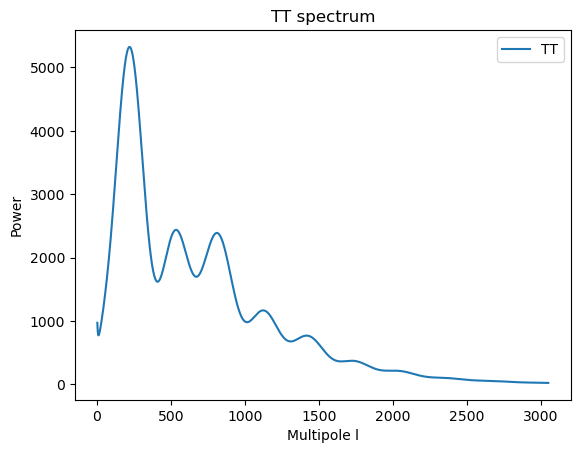

In [11]:
# Plot the total power spectrum

totCL = powers['total']
print(totCL.shape)
# Python CL arrays are all at base zero, including L=0, so the first two entries are not used. The first column is TT, the second EE, the third BB, and the fourth TE.

ls = np.arange(totCL.shape[0]) # Creates an array of multipoles from 0 to the maximum multipole in the power spectrum
plt.plot(ls[2:], totCL[2:, 0], label='TT')
plt.title('TT spectrum')
plt.xlabel('Multipole l')
plt.ylabel('Power')
plt.legend()
plt.show()

This plot illustrates the Angular Power Spectrum ($C_l$) of the temperature anisotropies in the Cosmic Microwave Background (CMB).

1. **The Sachs-Wolfe Plateau (Large Scales, $l \lesssim 100$)**

    This region corresponds to scales that were super-horizon at the time of recombination. Because they were too large for causal processes (such as sound waves) to act upon them, the fluctuations seen here are the "pure," frozen imprint of the quantum fluctuations generated during inflation. The power at these scales is dominated by the ordinary Sachs-Wolfe (SW) effect: the combination of the plasma's intrinsic temperature and the gravitational redshift or blueshift that photons experience when climbing out of primordial potential wells.

2. **The Acoustic Peaks (Intermediate Scales, $100 \lesssim l \lesssim 1500$)**

    These scales were sub-horizon and had enough time to undergo causal evolution. The spectrum captures a snapshot of the sound waves (acoustic oscillations) that were propagating through the primordial photon-baryon plasma.
    - <u>First Peak</u>>: Represents the phase of maximum compression. Waves on this specific scale had exactly enough time to fall into the gravitational potential wells and reach maximum density just as the universe became transparent. Its angular position ($l$) serves as a "standard ruler" that measures the sound horizon ($r_s$) and, consequently, the spatial geometry of the universe.
    - <u>Second Peak</u>: Represents the phase of maximum rarefaction (the first "bounce" outward).Peak Ratios: The relative heights of the odd peaks (compression) compared to the even peaks (rarefaction) act as a cosmic barometer. This effect, known as baryon loading, allows cosmologists to measure the density of baryons in the early universe.

3. **The Damping Tail (Small Scales, $l \gtrsim 1500$)**

    At these small scales, the spectrum exhibits a rapid exponential decay in power due to a process called Silk Damping (photon diffusion). Because recombination was not instantaneous, photons maintained a short mean free path. This allowed them to diffuse between hot and cold regions, mixing temperatures and effectively washing out the fine-grained anisotropies.

In [12]:
# Physical interpretation of the monopole and dipole terms in the CMB power spectrum:

monopole = totCL[0,0] # mean value of the temperature on the interface of the sky, the mean of the mean fluctuation is zero.
dipole = totCL[1,0] # Doppler effect of our velocity relative to the CMB, independent of the primordial universe
print('The monopole is: ', monopole)
print('The dipole is: ', dipole)

The monopole is:  0.0
The dipole is:  0.0


In [13]:
# Symbolic sources of the CMB temperature
monopole_source, ISW, doppler, quadrupole_service = camb.symbolic.get_scalar_temperature_sources()

In [14]:
early_ISW = sympy.Piecewise( (ISW, 1/a-1> 30),(0, True))  #redshift > 30
late_ISW = ISW - early_ISW

In [15]:
# Computing a power spectrum C_l separated for each of these sources

names = ['mon','ISW','eISW','LISW','dop', 'Q']
pars.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)

data = camb.get_results(pars)
dic  = data.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')

<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_21423/3722094478.py:9: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')


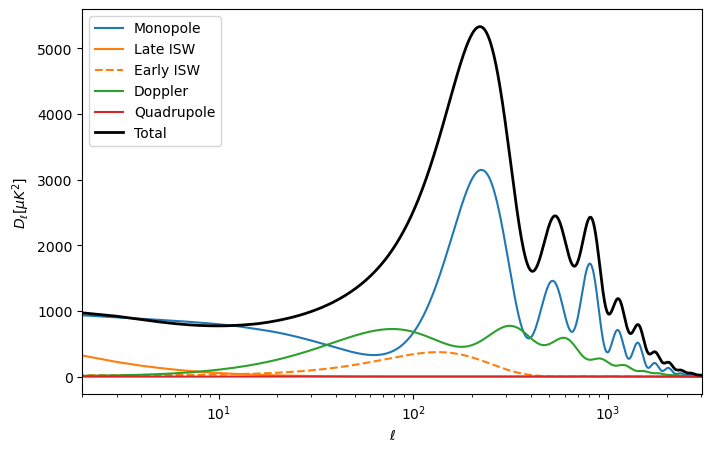

In [16]:
ls_TT =np.arange(dic['TxT'].shape[0])
plt.figure(figsize=(8,5))
plt.semilogx(ls_TT,dic['monxmon'], color='C0')
plt.semilogx(ls_TT,dic['LISWxLISW'], color='C1')
plt.semilogx(ls_TT,dic['eISWxeISW'], ls='--', color='C1')
plt.semilogx(ls_TT,dic['dopxdop'],color='C2')
plt.semilogx(ls_TT,dic['QxQ'], color='C3')
plt.semilogx(ls_TT,dic['TxT'], lw=2, color='k')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Monopole','Late ISW','Early ISW','Doppler','Quadrupole', 'Total'], loc = 'upper left');

1. **Monopole (Blue)**

    This does not refer to the physical $l=0$ monopole (which vanishes), but rather to the primary "source" term at the time of recombination. It represents the ordinary Sachs-Wolfe (SW) effect, given by the sum of the intrinsic temperature of the plasma and the gravitational potential. The peaks and troughs of this curve represent the acoustic oscillations: the first, third, and fifth peaks correspond to maximum compressions, while the second and fourth represent maximum rarefactions.

2. **Doppler (Green)**

    This is the Doppler effect caused by the peculiar velocity of the photon-baryon plasma at the time of recombination. The green curve has its peaks perfectly out of phase with the "Monopole" peaks. This is physically consistent: when the plasma reaches maximum compression (a Monopole peak), its velocity is momentarily zero (a Doppler trough).

3. **Early ISW (Dashed Orange)**

    This represents the Early Integrated Sachs-Wolfe (eISW) effect, caused by gravitational potentials that decay over time during the transition from the radiation-dominated era to the matter-dominated era. It exhibits a broad peak exactly at the scales of the first acoustic peak ($l \sim 100-200$). This represents the "radiation driving" effect, which amplifies the first peak and connects it to the Sachs-Wolfe plateau.

4. **Late ISW (Solid Orange)**

    This is the Late Integrated Sachs-Wolfe (lISW) effect. It is driven by the same physical mechanism as the early ISW effect but occurs at late times, caused by Dark Energy ($\Lambda$) making the gravitational potentials of large-scale structures decay. This contribution is significant only at the largest angular scales (very small $l$, $l \lesssim 10$). It is the reason why the Total curve (Black) rises at the far left of the spectrum.

5. **Quadrupole (Red)**

    This represents the contribution from the intrinsic quadrupole moment of the photon distribution. The line is essentially flat at zero, demonstrating that its direct contribution to the scalar temperature spectrum is completely negligible compared to all the other effects.

<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_21423/350099500.py:7: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/350099500.py:17: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/350099500.py:26: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/350099500.py:35: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')


Text(0.5, 1.0, 'Quadrupole effect')

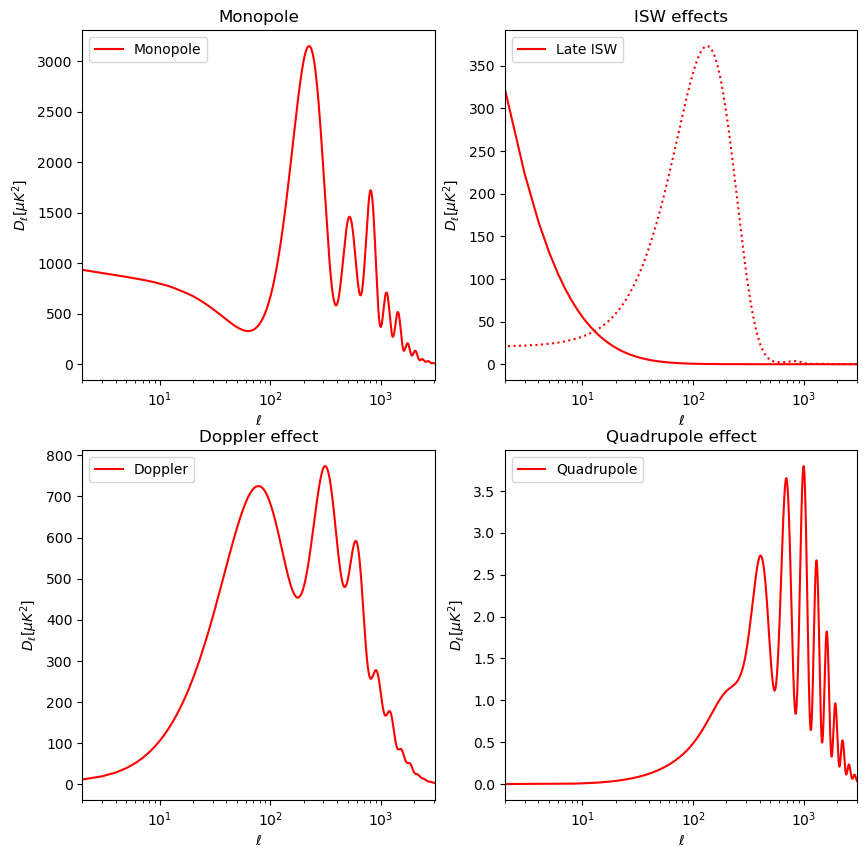

In [17]:
# Plot of different plots, monopole, dipole, ISW and quadrupole:

# Subplot for monopole
plt.subplots(2, 2, figsize=(10, 10))
plt.subplot(221)
plt.semilogx(ls_TT,dic['monxmon'], color='r')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Monopole'], loc = 'upper left')
plt.title('Monopole')

# Subplot for ISW effect
plt.subplot(222)
plt.semilogx(ls_TT,dic['LISWxLISW'], color='r', ls = '-')
plt.semilogx(ls_TT,dic['eISWxeISW'], ls=':', color='r')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Late ISW'], loc = 'upper left')
plt.title('ISW effects')

# Subplot for dipole effect
plt.subplot(223)
plt.semilogx(ls_TT,dic['dopxdop'],color='r')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Doppler'], loc = 'upper left')
plt.title('Doppler effect')

# Subplot for quadrupole effect
plt.subplot(224)
plt.semilogx(ls_TT,dic['QxQ'], color='r')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Quadrupole'], loc = 'upper left')
plt.title('Quadrupole effect')

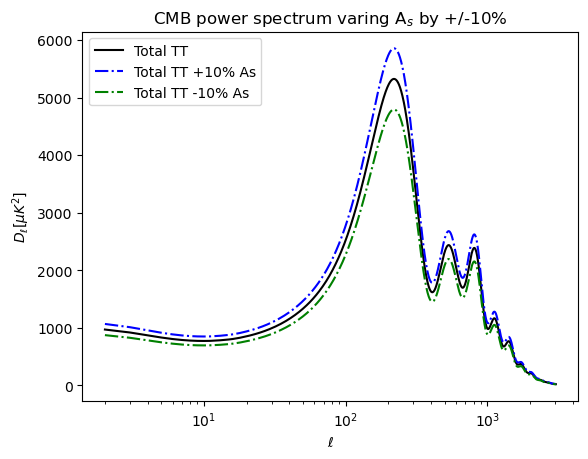

In [18]:
# Change As by +/-10%
A_s_pars_plus  = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
A_s_pars_minus = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
A_s_pars_minus.InitPower.As *= 90./100.
A_s_pars_plus.InitPower.As *= 110./100.

# Computing the results for this parameter

A_s_results_plus = camb.get_results(A_s_pars_plus)
A_s_results_minus = camb.get_results(A_s_pars_minus)

# Calculating the CMB power spectrum for the modified parameters

var_powers_plus = A_s_results_plus.get_cmb_power_spectra(A_s_pars_plus, CMB_unit='muK')
var_powers_minus = A_s_results_minus.get_cmb_power_spectra(A_s_pars_minus, CMB_unit='muK')

# Getting the total CMB power spectrum

var_totCL_plus = var_powers_plus['total']
var_totCL_minus = var_powers_minus['total']

# Plotting the CMB power spectrum
plt.figure()
plt.plot(ls[2:],totCL[2:,0], color='k',label='Total TT')
plt.plot(ls[2:],var_totCL_plus[2:,0], color='b',ls = '-.',label='Total TT +10% As')
plt.plot(ls[2:],var_totCL_minus[2:,0], color='g',ls = '-.',label='Total TT -10% As')
plt.legend()
plt.xlabel(r'$\ell$')
plt.xscale('log')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.title('CMB power spectrum varing A$_s$ by +/-10%')
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:57: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:57: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_21423/3524727649.py:21: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/3524727649.py:35: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/3524727649.py:46: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/3524727649.py:57: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')


Text(0.5, 1.0, 'Quadrupole effect')

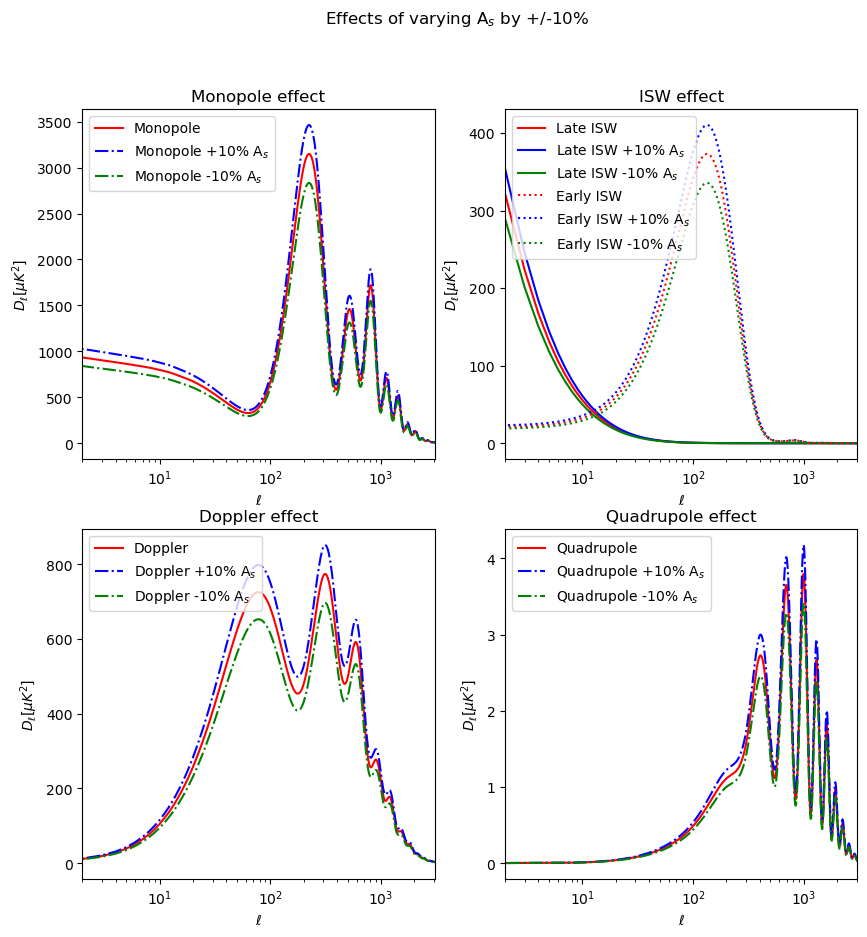

In [19]:
A_s_pars_minus.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)
A_s_pars_plus.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)

A_s_data_plus = camb.get_results(A_s_pars_plus)
A_s_data_minus = camb.get_results(A_s_pars_minus)

A_s_dic_plus = A_s_data_plus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')
A_s_dic_minus = A_s_data_minus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')

# Plot of different plots, monopole, dipole, ISW and quadrupole

# Subplot for monopole effect
plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle('Effects of varying A$_s$ by +/-10%')
plt.subplot(221)
plt.semilogx(ls_TT,dic['monxmon'], color='r')
plt.semilogx(ls_TT,A_s_dic_plus['monxmon'], color='b',ls = '-.')
plt.semilogx(ls_TT,A_s_dic_minus['monxmon'], color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Monopole','Monopole +10% A$_s$','Monopole -10% A$_s$'], loc = 'upper left')
plt.title('Monopole effect')

# Subplot for ISW effect
plt.subplot(222)
plt.semilogx(ls_TT,dic['LISWxLISW'], color='r', ls = '-')
plt.semilogx(ls_TT,A_s_dic_plus['LISWxLISW'], color='b',ls = '-')
plt.semilogx(ls_TT,A_s_dic_minus['LISWxLISW'], color='g',ls = '-')
plt.semilogx(ls_TT,dic['eISWxeISW'], ls=':', color='r')
plt.semilogx(ls_TT,A_s_dic_plus['eISWxeISW'], ls=':', color='b')
plt.semilogx(ls_TT,A_s_dic_minus['eISWxeISW'], ls=':', color='g')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Late ISW','Late ISW +10% A$_s$','Late ISW -10% A$_s$','Early ISW','Early ISW +10% A$_s$','Early ISW -10% A$_s$'], loc = 'upper left')
plt.title('ISW effect')

# Subplot for dipole effect
plt.subplot(223)
plt.semilogx(ls_TT,dic['dopxdop'],color='r')
plt.semilogx(ls_TT,A_s_dic_plus['dopxdop'],color='b',ls = '-.')
plt.semilogx(ls_TT,A_s_dic_minus['dopxdop'],color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Doppler','Doppler +10% A$_s$','Doppler -10% A$_s$'], loc = 'upper left')
plt.title('Doppler effect')

# Subplot for quadrupole effect
plt.subplot(224)
plt.semilogx(ls_TT,dic['QxQ'], color='r')
plt.semilogx(ls_TT,A_s_dic_plus['QxQ'], color='b',ls = '-.')
plt.semilogx(ls_TT,A_s_dic_minus['QxQ'], color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Quadrupole','Quadrupole +10% A$_s$','Quadrupole -10% A$_s$'], loc = 'upper left')
plt.title('Quadrupole effect')


$A_s$ (Primordial Scalar Amplitude)

$A_s$ normalizes the primordial power spectrum, $\mathcal{P}_{\mathcal{R}}(k)$; more initial power translates to larger anisotropies across all scales.

Modifying $A_s$—the amplitude of the primordial curvature perturbations—results in a uniform scaling of the overall amplitude of the CMB anisotropies, without altering the underlying shape of the spectrum. Consequently, all the acoustic peaks rise or fall strictly in proportion, since the angular power spectrum scales linearly with this initial amplitude: $C_l^{TT} \propto A_s$.

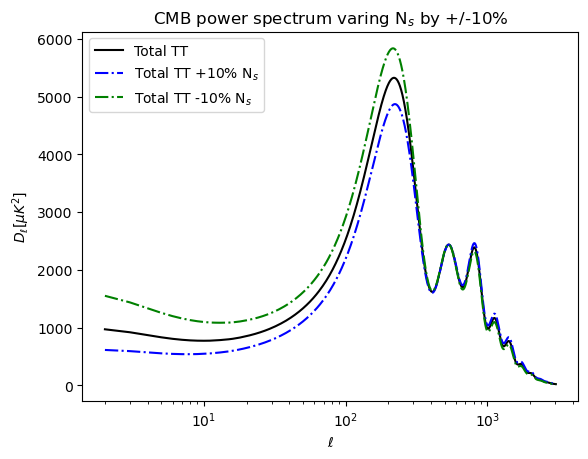

In [20]:
# Changing ns by +/-10%

N_s_pars_plus  = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
N_s_pars_minus = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
N_s_pars_minus.InitPower.ns *= 90./100.
N_s_pars_plus.InitPower.ns *= 110./100.

# Computing the results for this parameter

N_s_results_plus = camb.get_results(N_s_pars_plus)
N_s_results_minus = camb.get_results(N_s_pars_minus)

# Calculating the CMB power spectrum for the modified parameters

N_s_powers_plus = N_s_results_plus.get_cmb_power_spectra(N_s_pars_plus, CMB_unit='muK')
N_s_powers_minus = N_s_results_minus.get_cmb_power_spectra(N_s_pars_minus, CMB_unit='muK')

# Getting the total CMB power spectrum

N_s_totCL_plus = N_s_powers_plus['total']
N_s_totCL_minus = N_s_powers_minus['total']

# Plotting the CMB power spectrum
plt.figure()
plt.plot(ls[2:],totCL[2:,0], color='k',label='Total TT')
plt.plot(ls[2:],N_s_totCL_plus[2:,0], color='b',ls = '-.',label='Total TT +10% N$_s$')
plt.plot(ls[2:],N_s_totCL_minus[2:,0], color='g',ls = '-.',label='Total TT -10% N$_s$')
plt.legend()
plt.xlabel(r'$\ell$')
plt.xscale('log')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.title('CMB power spectrum varing N$_s$ by +/-10%')
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:57: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:57: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_21423/1077970900.py:21: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/1077970900.py:35: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/1077970900.py:46: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/1077970900.py:57: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')


Text(0.5, 1.0, 'Quadrupole effect')

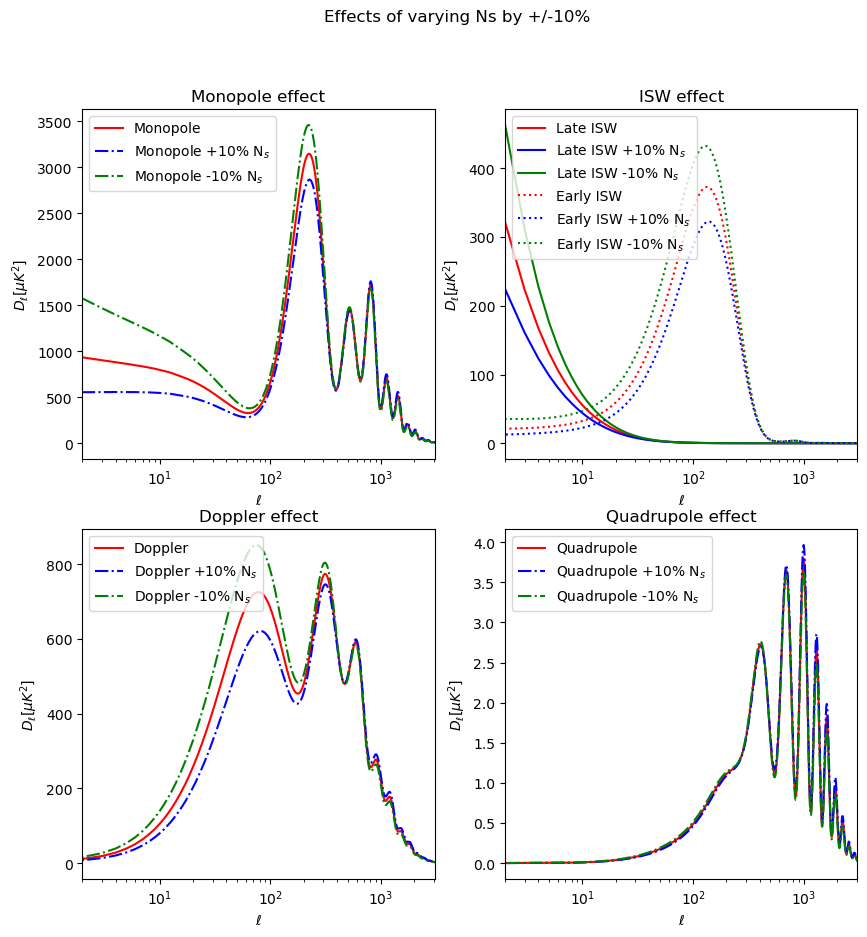

In [21]:
N_s_pars_minus.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)
N_s_pars_plus.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)

N_s_data_plus = camb.get_results(N_s_pars_plus)
N_s_data_minus = camb.get_results(N_s_pars_minus)

N_s_dic_plus = N_s_data_plus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')
N_s_dic_minus = N_s_data_minus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')

# Plot of different plots: monopole, dipole, ISW and quadrupole

# Subplot for monopole effect
plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle('Effects of varying Ns by +/-10%')
plt.subplot(221)
plt.semilogx(ls_TT,dic['monxmon'], color='r')
plt.semilogx(ls_TT,N_s_dic_plus['monxmon'], color='b',ls = '-.')
plt.semilogx(ls_TT,N_s_dic_minus['monxmon'], color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Monopole','Monopole +10% N$_s$','Monopole -10% N$_s$'], loc = 'upper left')
plt.title('Monopole effect')

# Subplot for ISW effect
plt.subplot(222)
plt.semilogx(ls_TT,dic['LISWxLISW'], color='r', ls = '-')
plt.semilogx(ls_TT,N_s_dic_plus['LISWxLISW'], color='b',ls = '-')
plt.semilogx(ls_TT,N_s_dic_minus['LISWxLISW'], color='g',ls = '-')
plt.semilogx(ls_TT,dic['eISWxeISW'], ls=':', color='r')
plt.semilogx(ls_TT,N_s_dic_plus['eISWxeISW'], ls=':', color='b')
plt.semilogx(ls_TT,N_s_dic_minus['eISWxeISW'], ls=':', color='g')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Late ISW','Late ISW +10% N$_s$','Late ISW -10% N$_s$','Early ISW','Early ISW +10% N$_s$','Early ISW -10% N$_s$'], loc = 'upper left')
plt.title('ISW effect')

# Subplot for dipole effect
plt.subplot(223)
plt.semilogx(ls_TT,dic['dopxdop'],color='r')
plt.semilogx(ls_TT,N_s_dic_plus['dopxdop'],color='b',ls = '-.')
plt.semilogx(ls_TT,N_s_dic_minus['dopxdop'],color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Doppler','Doppler +10% N$_s$','Doppler -10% N$_s$'], loc = 'upper left')
plt.title('Doppler effect')

# Subplot for quadrupole effect
plt.subplot(224)
plt.semilogx(ls_TT,dic['QxQ'], color='r')
plt.semilogx(ls_TT,N_s_dic_plus['QxQ'], color='b',ls = '-.')
plt.semilogx(ls_TT,N_s_dic_minus['QxQ'], color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Quadrupole','Quadrupole +10% N$_s$','Quadrupole -10% N$_s$'], loc = 'upper left')
plt.title('Quadrupole effect')


$n_s$ (Scalar Spectral Index)

Modifying $n_s$ alters the "tilt" of the primordial power spectrum. Specifically, increasing $n_s$ enhances the relative power at small scales (high multipoles $l$) and slightly reduces it at large scales (low multipoles $l$).

This effect is particularly evident in the monopole and Integrated Sachs-Wolfe (ISW) contributions, which dominate at large scales, whereas the Doppler contribution and the overall structure of the acoustic peaks are more heavily influenced at intermediate and high $l$.

Therefore, unlike $A_s$, which uniformly rescales all amplitudes, $n_s$ does not simply shift the entire spectrum up or down; rather, it changes the relative weighting across the different angular scales.

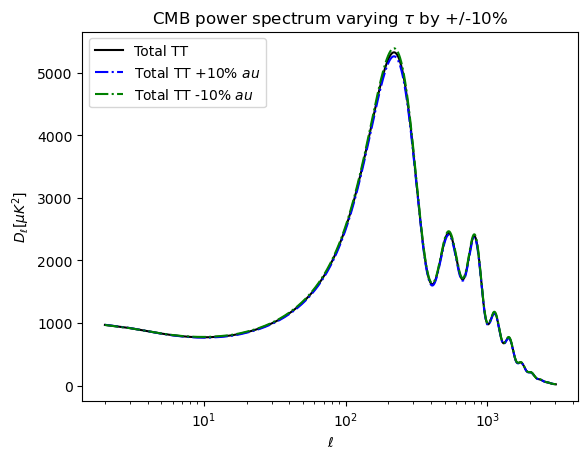

In [22]:
# Changing tau by +/-10%

tau_pars_plus  = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
tau_pars_minus = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
tau_pars_minus.Reion.optical_depth *= 90./100.
tau_pars_plus.Reion.optical_depth *= 110./100.

# Computing the results for this parameter

tau_results_plus = camb.get_results(tau_pars_plus)
tau_results_minus = camb.get_results(tau_pars_minus)

# Computing the CMB power spectrum for the modified parameter

tau_powers_plus = tau_results_plus.get_cmb_power_spectra(tau_pars_plus, CMB_unit='muK')
tau_powers_minus = tau_results_minus.get_cmb_power_spectra(tau_pars_minus, CMB_unit='muK')

# Getting the total CMB power spectrum

tau_totCL_plus = tau_powers_plus['total']
tau_totCL_minus = tau_powers_minus['total']


# Plotting the CMB power spectrum
plt.figure()
plt.plot(ls[2:],totCL[2:,0], color='k',label='Total TT')
plt.plot(ls[2:],tau_totCL_plus[2:,0], color='b',ls = '-.',label='Total TT +10% $\tau$')
plt.plot(ls[2:],tau_totCL_minus[2:,0], color='g',ls = '-.',label='Total TT -10% $\tau$')
plt.legend()
plt.xlabel(r'$\ell$')
plt.xscale('log')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.title(r'CMB power spectrum varying $\tau$ by +/-10%')
plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:49: SyntaxWarning: invalid escape sequence '\e'
<>:60: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:49: SyntaxWarning: invalid escape sequence '\e'
<>:60: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_21423/989693076.py:24: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/989693076.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/989693076.py:49: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/989693076.py:60: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')


Text(0.5, 1.0, 'Quadrupole effect')

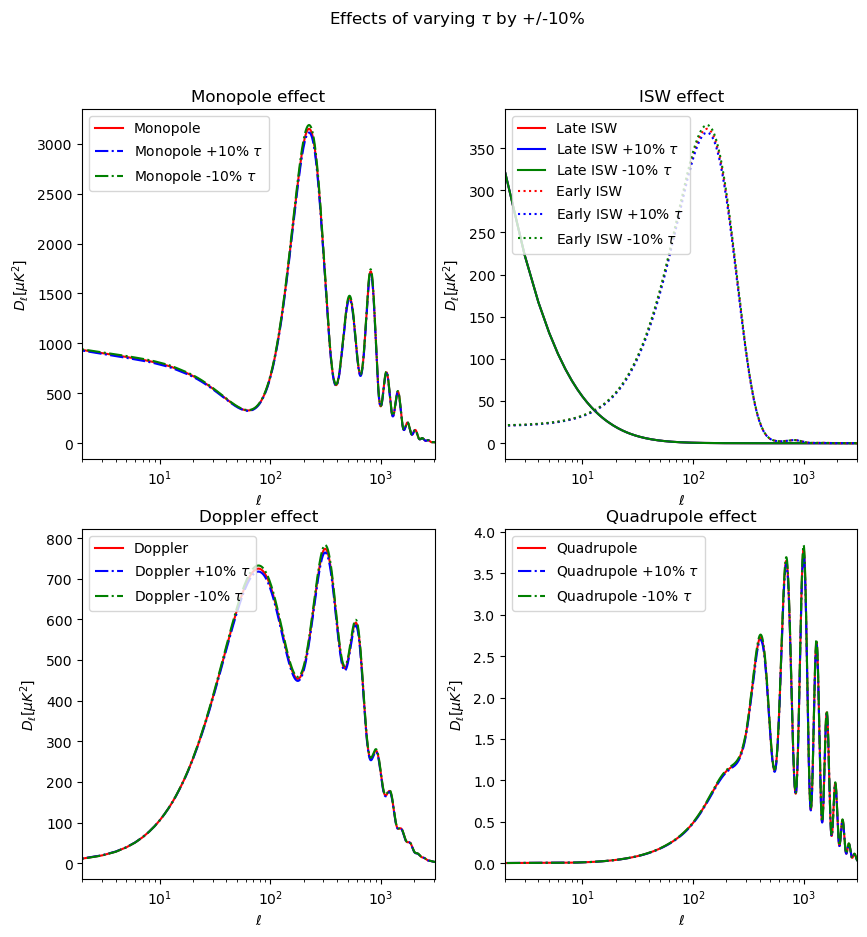

In [23]:
from cmath import tau


tau_pars_minus.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)
tau_pars_plus.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)

tau_data_plus = camb.get_results(tau_pars_plus)
tau_data_minus = camb.get_results(tau_pars_minus)

tau_dic_plus = tau_data_plus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')
tau_dic_minus = tau_data_minus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')

# Plot of different plots: monopole, dipole, ISW and quadrupole

# Subplot for monopole effect
plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle(r'Effects of varying $\tau$ by +/-10%')
plt.subplot(221)
plt.semilogx(ls_TT,dic['monxmon'], color='r')
plt.semilogx(ls_TT,tau_dic_plus['monxmon'], color='b',ls = '-.')
plt.semilogx(ls_TT,tau_dic_minus['monxmon'], color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend([r'Monopole', r'Monopole +10% $\tau$', r'Monopole -10% $\tau$'], loc = 'upper left')
plt.title('Monopole effect')

# Subplot for ISW effect
plt.subplot(222)
plt.semilogx(ls_TT,dic['LISWxLISW'], color='r', ls = '-')
plt.semilogx(ls_TT,tau_dic_plus['LISWxLISW'], color='b',ls = '-')
plt.semilogx(ls_TT,tau_dic_minus['LISWxLISW'], color='g',ls = '-')
plt.semilogx(ls_TT,dic['eISWxeISW'], ls=':', color='r')
plt.semilogx(ls_TT,tau_dic_plus['eISWxeISW'], ls=':', color='b')
plt.semilogx(ls_TT,tau_dic_minus['eISWxeISW'], ls=':', color='g')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend([r'Late ISW', r'Late ISW +10% $\tau$', r'Late ISW -10% $\tau$', r'Early ISW', r'Early ISW +10% $\tau$', r'Early ISW -10% $\tau  $'], loc = 'upper left')
plt.title('ISW effect')

# Subplot for dipole effect
plt.subplot(223)
plt.semilogx(ls_TT,dic['dopxdop'],color='r')
plt.semilogx(ls_TT,tau_dic_plus['dopxdop'],color='b',ls = '-.')
plt.semilogx(ls_TT,tau_dic_minus['dopxdop'],color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend([r'Doppler', r'Doppler +10% $\tau$', r'Doppler -10% $\tau$'], loc = 'upper left')
plt.title('Doppler effect')

# Subplot for quadrupole effect
plt.subplot(224)
plt.semilogx(ls_TT,dic['QxQ'], color='r')
plt.semilogx(ls_TT,tau_dic_plus['QxQ'], color='b',ls = '-.')
plt.semilogx(ls_TT,tau_dic_minus['QxQ'], color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend([r'Quadrupole', r'Quadrupole +10% $\tau$', r'Quadrupole -10% $\tau$'], loc = 'upper left')
plt.title('Quadrupole effect')

$\tau$ (Optical Depth to Reionization)

Modifying $\tau$, the optical depth to reionization, acts as an exponential damping factor on the CMB temperature anisotropies. Specifically, at high multipoles ($l \gtrsim 100$), the power spectrum is attenuated approximately according to $C_l^{TT} \propto A_s e^{-2\tau}$.

By varying $\tau$, all physical contributions to the spectrum (Monopole, Doppler, ISW, and Quadrupole) undergo a similar and consistent reduction in amplitude across these scales, although the overall visual effect on the spectrum is relatively subtle.

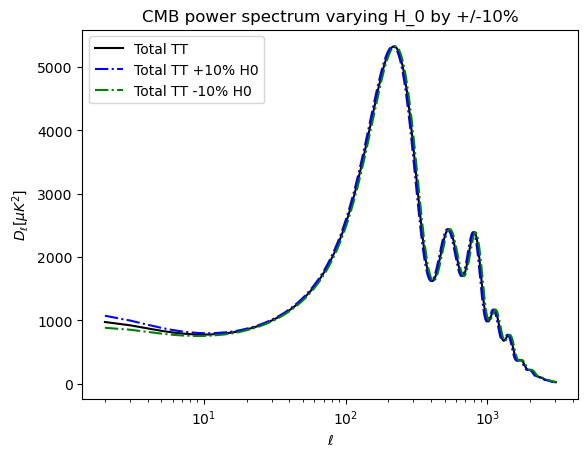

In [24]:
# Changing H0 by +/-10%

H0_pars_plus  = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
H0_pars_minus = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
H0_pars_minus.H0 *= 90./100.
H0_pars_plus.H0 *= 110./100.

# Computing the results for this parameter

H0_results_plus = camb.get_results(H0_pars_plus)
H0_results_minus = camb.get_results(H0_pars_minus)

# Calculating the CMB power spectrum for the modified parameter

H0_powers_plus = H0_results_plus.get_cmb_power_spectra(H0_pars_plus, CMB_unit='muK')
H0_powers_minus = H0_results_minus.get_cmb_power_spectra(H0_pars_minus, CMB_unit='muK')

# Obtaining the total CMB power spectrum

H0_totCL_plus = H0_powers_plus['total']
H0_totCL_minus = H0_powers_minus['total']


# Plotting the CMB power spectrum
plt.figure()
plt.plot(ls[2:],totCL[2:,0], color='k',label='Total TT')
plt.plot(ls[2:],H0_totCL_plus[2:,0], color='b',ls = '-.',label='Total TT +10% H0')
plt.plot(ls[2:],H0_totCL_minus[2:,0], color='g',ls = '-.',label='Total TT -10% H0')
plt.legend()
plt.xlabel(r'$\ell$')
plt.xscale('log')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.title(r'CMB power spectrum varying H_0 by +/-10%')
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:57: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:57: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_21423/1381020280.py:21: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/1381020280.py:35: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/1381020280.py:46: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_21423/1381020280.py:57: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')


Text(0.5, 1.0, 'Quadrupole effect')

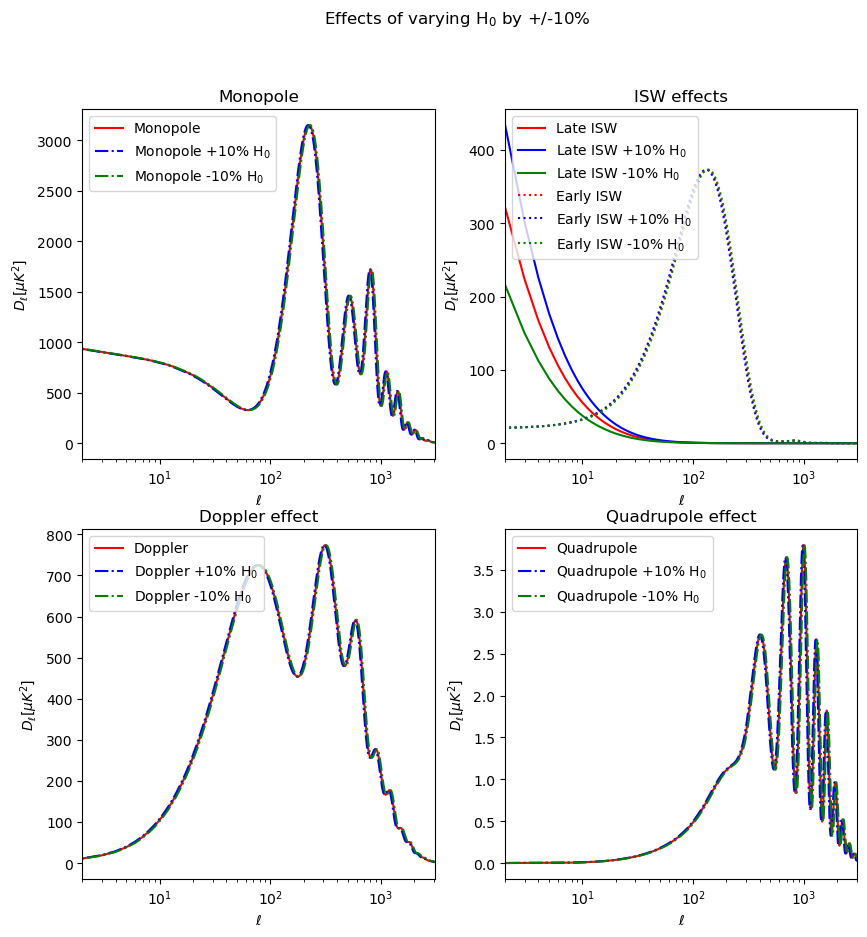

In [25]:
H0_pars_minus.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)
H0_pars_plus.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)

H0_data_plus = camb.get_results(H0_pars_plus)
H0_data_minus = camb.get_results(H0_pars_minus)

H0_dic_plus = H0_data_plus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')
H0_dic_minus = H0_data_minus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')

# grafico in una griglia di grafici, monopolo, dipolo ,ISW e quadrupolo

# Subplot per monopolo
plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle(r'Effects of varying H$_0$ by +/-10%')
plt.subplot(221)
plt.semilogx(ls_TT,dic['monxmon'], color='r')
plt.semilogx(ls_TT,H0_dic_plus['monxmon'], color='b',ls = '-.')
plt.semilogx(ls_TT,H0_dic_minus['monxmon'], color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend([r'Monopole', r'Monopole +10% H$_0$', r'Monopole -10% H$_0$'], loc = 'upper left')
plt.title('Monopole')

# Subplot per effetto ISW
plt.subplot(222)
plt.semilogx(ls_TT,dic['LISWxLISW'], color='r', ls = '-')
plt.semilogx(ls_TT,H0_dic_plus['LISWxLISW'], color='b',ls = '-')
plt.semilogx(ls_TT,H0_dic_minus['LISWxLISW'], color='g',ls = '-')
plt.semilogx(ls_TT,dic['eISWxeISW'], ls=':', color='r')
plt.semilogx(ls_TT,H0_dic_plus['eISWxeISW'], ls=':', color='b')
plt.semilogx(ls_TT,H0_dic_minus['eISWxeISW'], ls=':', color='g')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend([r'Late ISW', r'Late ISW +10% H$_0$', r'Late ISW -10% H$_0$', r'Early ISW', r'Early ISW +10% H$_0$', r'Early ISW -10% H$_0$'], loc = 'upper left')
plt.title('ISW effects')

# Subplot per effetto dipolo
plt.subplot(223)
plt.semilogx(ls_TT,dic['dopxdop'],color='r')
plt.semilogx(ls_TT,H0_dic_plus['dopxdop'],color='b',ls = '-.')
plt.semilogx(ls_TT,H0_dic_minus['dopxdop'],color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend([r'Doppler', r'Doppler +10% H$_0$', r'Doppler -10% H$_0$'], loc = 'upper left')
plt.title('Doppler effect')

# Subplot per effetto Quadrupolo
plt.subplot(224)
plt.semilogx(ls_TT,dic['QxQ'], color='r')
plt.semilogx(ls_TT,H0_dic_plus['QxQ'], color='b',ls = '-.')
plt.semilogx(ls_TT,H0_dic_minus['QxQ'], color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend([r'Quadrupole', r'Quadrupole +10% H$_0$', r'Quadrupole -10% H$_0$'], loc = 'upper left')
plt.title('Quadrupole effect')

$H_0$ (Hubble Constant)A small variation in $H_0$ (e.g., by 10%) produces a relatively minor overall effect on the power spectrum.

In a flat $\Lambda\text{CDM}$ universe, the Hubble parameter evolves as: $H(a) = H_0\sqrt{\Omega_m a^{-3} + \Omega_\Lambda}$

A higher value of $H_0$ implies a smaller angular diameter distance to the surface of last scattering. Consequently, the acoustic peaks shift toward higher multipoles ($\ell$); conversely, a lower $H_0$ shifts them toward lower multipoles.

The amplitude of the spectrum changes very weakly; the primary impact of $H_0$ is geometric, directly affecting the characteristic angular scale of the acoustic peaks.

<>:31: SyntaxWarning: invalid escape sequence '\O'
<>:32: SyntaxWarning: invalid escape sequence '\O'
<>:37: SyntaxWarning: invalid escape sequence '\O'
<>:31: SyntaxWarning: invalid escape sequence '\O'
<>:32: SyntaxWarning: invalid escape sequence '\O'
<>:37: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_21423/3081683948.py:31: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(ls[2:],omega_b_totCL_plus[2:,0], color='b',ls = '-.',label='Total TT +10% $\Omega_b$')
/tmp/ipykernel_21423/3081683948.py:32: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(ls[2:],omega_b_totCL_minus[2:,0], color='g',ls = '-.',label='Total TT -10% $\Omega_b$')
/tmp/ipykernel_21423/3081683948.py:37: SyntaxWarning: invalid escape sequence '\O'
  plt.title('CMB power spectrum varing $\Omega_b$ by +/-10%')


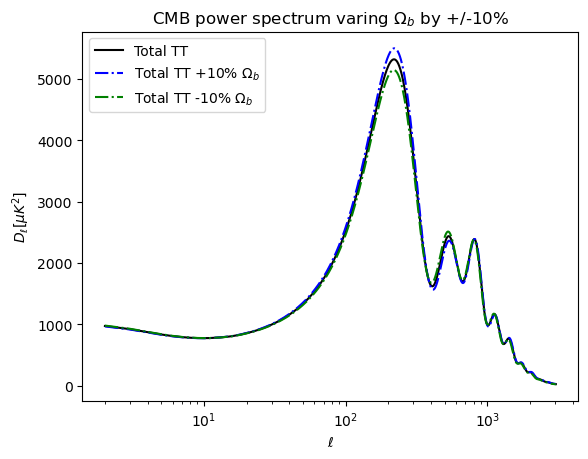

In [26]:
# Changing Omega_b by +/-10%

omega_b_pars_plus  = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
omega_b_pars_minus = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
omega_b_pars_minus.ombh2 *= 90./100.
omega_b_pars_plus.ombh2 *= 110./100.

# Computing the results for this parameter

omega_b_results_plus = camb.get_results(omega_b_pars_plus)
omega_b_results_minus = camb.get_results(omega_b_pars_minus)

# Calculating the CMB power spectrum for the modified parameter

omega_b_powers_plus = omega_b_results_plus.get_cmb_power_spectra(omega_b_pars_plus, CMB_unit='muK')
omega_b_powers_minus = omega_b_results_minus.get_cmb_power_spectra(omega_b_pars_minus, CMB_unit='muK')

# Obtaining the total CMB power spectrum

omega_b_totCL_plus = omega_b_powers_plus['total']
omega_b_totCL_minus = omega_b_powers_minus['total']


# Plotting the CMB power spectrum
plt.figure()
plt.plot(ls[2:],totCL[2:,0], color='k',label='Total TT')
plt.plot(ls[2:],omega_b_totCL_plus[2:,0], color='b',ls = '-.',label='Total TT +10% $\Omega_b$')
plt.plot(ls[2:],omega_b_totCL_minus[2:,0], color='g',ls = '-.',label='Total TT -10% $\Omega_b$')
plt.legend()
plt.xlabel(r'$\ell$')
plt.xscale('log')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.title('CMB power spectrum varing $\Omega_b$ by +/-10%')
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\O'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\O'
<>:24: SyntaxWarning: invalid escape sequence '\O'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:38: SyntaxWarning: invalid escape sequence '\O'
<>:38: SyntaxWarning: invalid escape sequence '\O'
<>:38: SyntaxWarning: invalid escape sequence '\O'
<>:38: SyntaxWarning: invalid escape sequence '\O'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:49: SyntaxWarning: invalid escape sequence '\O'
<>:49: SyntaxWarning: invalid escape sequence '\O'
<>:57: SyntaxWarning: invalid escape sequence '\e'
<>:60: SyntaxWarning: invalid escape sequence '\O'
<>:60: SyntaxWarning: invalid escape sequence '\O'
<>:16: SyntaxWarning: invalid escape sequence '\O'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\O'
<>:24: SyntaxWarning: invalid escape sequence '\O'
<>:35: SyntaxWarning: invalid e

Text(0.5, 1.0, 'Quadrupole effect')

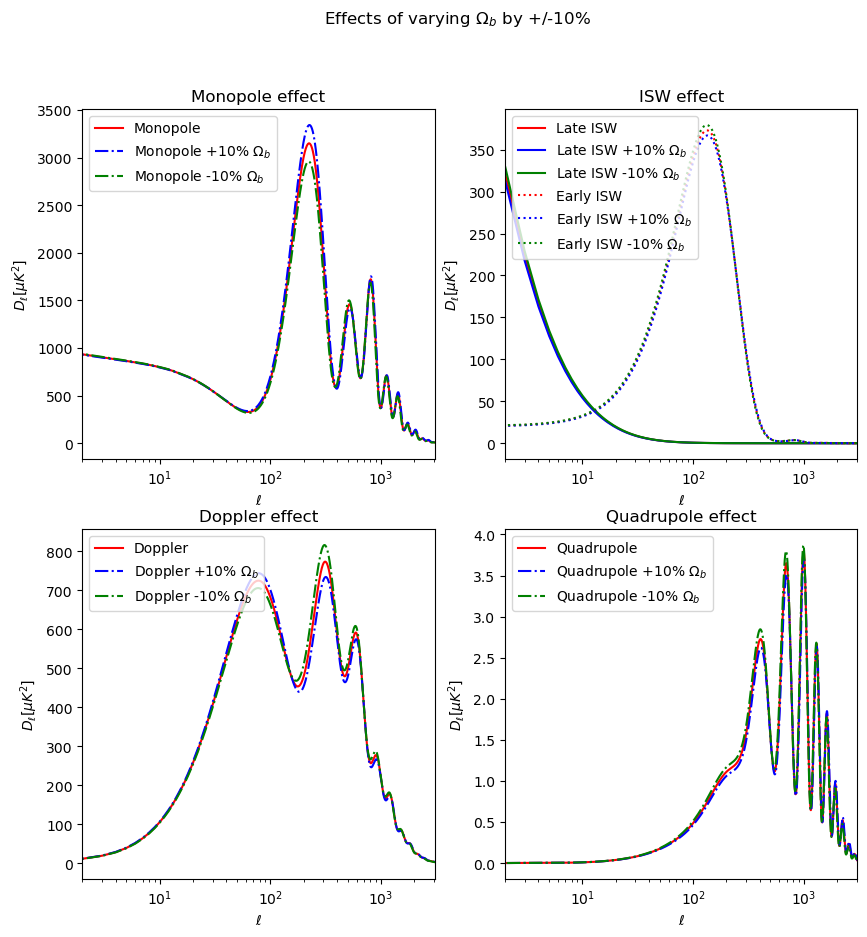

In [27]:
omega_b_pars_minus.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)
omega_b_pars_plus.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)

omega_b_data_plus = camb.get_results(omega_b_pars_plus)
omega_b_data_minus = camb.get_results(omega_b_pars_minus)

omega_b_dic_plus = omega_b_data_plus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')
omega_b_dic_minus = omega_b_data_minus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')

# Plot of different plots: monopole, dipole, ISW and quadrupole

# Subplot for monopole effect
plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle('Effects of varying $\Omega_b$ by +/-10%')
plt.subplot(221)
plt.semilogx(ls_TT,dic['monxmon'], color='r')
plt.semilogx(ls_TT,omega_b_dic_plus['monxmon'], color='b',ls = '-.')
plt.semilogx(ls_TT,omega_b_dic_minus['monxmon'], color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Monopole','Monopole +10% $\Omega_b$','Monopole -10% $\Omega_b$'], loc = 'upper left')
plt.title('Monopole effect')

# Subplot for ISW effect
plt.subplot(222)
plt.semilogx(ls_TT,dic['LISWxLISW'], color='r', ls = '-')
plt.semilogx(ls_TT,omega_b_dic_plus['LISWxLISW'], color='b',ls = '-')
plt.semilogx(ls_TT,omega_b_dic_minus['LISWxLISW'], color='g',ls = '-')
plt.semilogx(ls_TT,dic['eISWxeISW'], ls=':', color='r')
plt.semilogx(ls_TT,omega_b_dic_plus['eISWxeISW'], ls=':', color='b')
plt.semilogx(ls_TT,omega_b_dic_minus['eISWxeISW'], ls=':', color='g')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Late ISW','Late ISW +10% $\Omega_b$','Late ISW -10% $\Omega_b$','Early ISW','Early ISW +10% $\Omega_b$','Early ISW -10% $\Omega_b$'], loc = 'upper left')
plt.title('ISW effect')

# Subplot for dipole effect
plt.subplot(223)
plt.semilogx(ls_TT,dic['dopxdop'],color='r')
plt.semilogx(ls_TT,omega_b_dic_plus['dopxdop'],color='b',ls = '-.')
plt.semilogx(ls_TT,omega_b_dic_minus['dopxdop'],color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Doppler','Doppler +10% $\Omega_b$','Doppler -10% $\Omega_b$'], loc = 'upper left')
plt.title('Doppler effect')

# Subplot for quadrupole effect
plt.subplot(224)
plt.semilogx(ls_TT,dic['QxQ'], color='r')
plt.semilogx(ls_TT,omega_b_dic_plus['QxQ'], color='b',ls = '-.')
plt.semilogx(ls_TT,omega_b_dic_minus['QxQ'], color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Quadrupole','Quadrupole +10% $\Omega_b$','Quadrupole -10% $\Omega_b$'], loc = 'upper left')
plt.title('Quadrupole effect')

$\Omega_b h^2$ (Physical Baryon Density)

A 10% variation in the physical baryon density parameter, $\Omega_b h^2$, produces a relatively subtle effect on the TT power spectrum, though it remains perfectly consistent with the underlying physics.

Increasing $\Omega_b h^2$ tends to slightly enhance the amplitude of the first peak relative to the second, while decreasing it produces the exact opposite effect (even if the difference is difficult to discern qualitatively at a quick glance).

This behavior is driven by a phenomenon known as baryon loading. The presence of baryons adds inertia to the primordial photon-baryon plasma. This increased mass deepens the potential wells, making the phases of maximum compression (the odd-numbered peaks) more pronounced compared to the phases of maximum rarefaction (the even-numbered peaks, where the plasma rebounds against gravity).

<>:31: SyntaxWarning: invalid escape sequence '\O'
<>:32: SyntaxWarning: invalid escape sequence '\O'
<>:37: SyntaxWarning: invalid escape sequence '\O'
<>:31: SyntaxWarning: invalid escape sequence '\O'
<>:32: SyntaxWarning: invalid escape sequence '\O'
<>:37: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_21423/870517987.py:31: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(ls[2:],omega_c_totCL_plus[2:,0], color='b',ls = '-.',label='Total TT +10% $\Omega_c$')
/tmp/ipykernel_21423/870517987.py:32: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(ls[2:],omega_c_totCL_minus[2:,0], color='g',ls = '-.',label='Total TT -10% $\Omega_c$')
/tmp/ipykernel_21423/870517987.py:37: SyntaxWarning: invalid escape sequence '\O'
  plt.title('CMB power spectrum varing $\Omega_c$ by +/-10%')


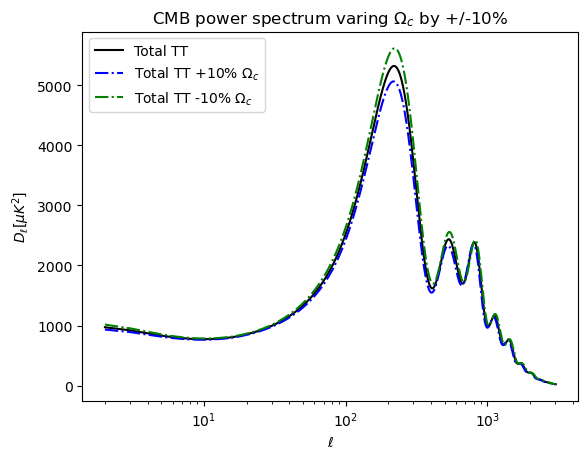

In [28]:
# Changing Omega_c by +/-10%

omega_c_pars_plus  = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
omega_c_pars_minus = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
omega_c_pars_minus.omch2 *= 90./100.
omega_c_pars_plus.omch2 *= 110./100.

# Computing the results for this parameter

omega_c_results_plus = camb.get_results(omega_c_pars_plus)
omega_c_results_minus = camb.get_results(omega_c_pars_minus)

# Calculating the CMB power spectrum for the modified parameter

omega_c_powers_plus = omega_c_results_plus.get_cmb_power_spectra(omega_c_pars_plus, CMB_unit='muK')
omega_c_powers_minus = omega_c_results_minus.get_cmb_power_spectra(omega_c_pars_minus, CMB_unit='muK')

# Obtaining the total CMB power spectrum

omega_c_totCL_plus = omega_c_powers_plus['total']
omega_c_totCL_minus = omega_c_powers_minus['total']


# Plotting the CMB power spectrum
plt.figure()
plt.plot(ls[2:],totCL[2:,0], color='k',label='Total TT')
plt.plot(ls[2:],omega_c_totCL_plus[2:,0], color='b',ls = '-.',label='Total TT +10% $\Omega_c$')
plt.plot(ls[2:],omega_c_totCL_minus[2:,0], color='g',ls = '-.',label='Total TT -10% $\Omega_c$')
plt.legend()
plt.xlabel(r'$\ell$')
plt.xscale('log')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.title('CMB power spectrum varing $\Omega_c$ by +/-10%')
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\O'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\O'
<>:24: SyntaxWarning: invalid escape sequence '\O'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:38: SyntaxWarning: invalid escape sequence '\O'
<>:38: SyntaxWarning: invalid escape sequence '\O'
<>:38: SyntaxWarning: invalid escape sequence '\O'
<>:38: SyntaxWarning: invalid escape sequence '\O'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:49: SyntaxWarning: invalid escape sequence '\O'
<>:49: SyntaxWarning: invalid escape sequence '\O'
<>:57: SyntaxWarning: invalid escape sequence '\e'
<>:60: SyntaxWarning: invalid escape sequence '\O'
<>:60: SyntaxWarning: invalid escape sequence '\O'
<>:16: SyntaxWarning: invalid escape sequence '\O'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\O'
<>:24: SyntaxWarning: invalid escape sequence '\O'
<>:35: SyntaxWarning: invalid e

Text(0.5, 1.0, 'Quadrupole effect')

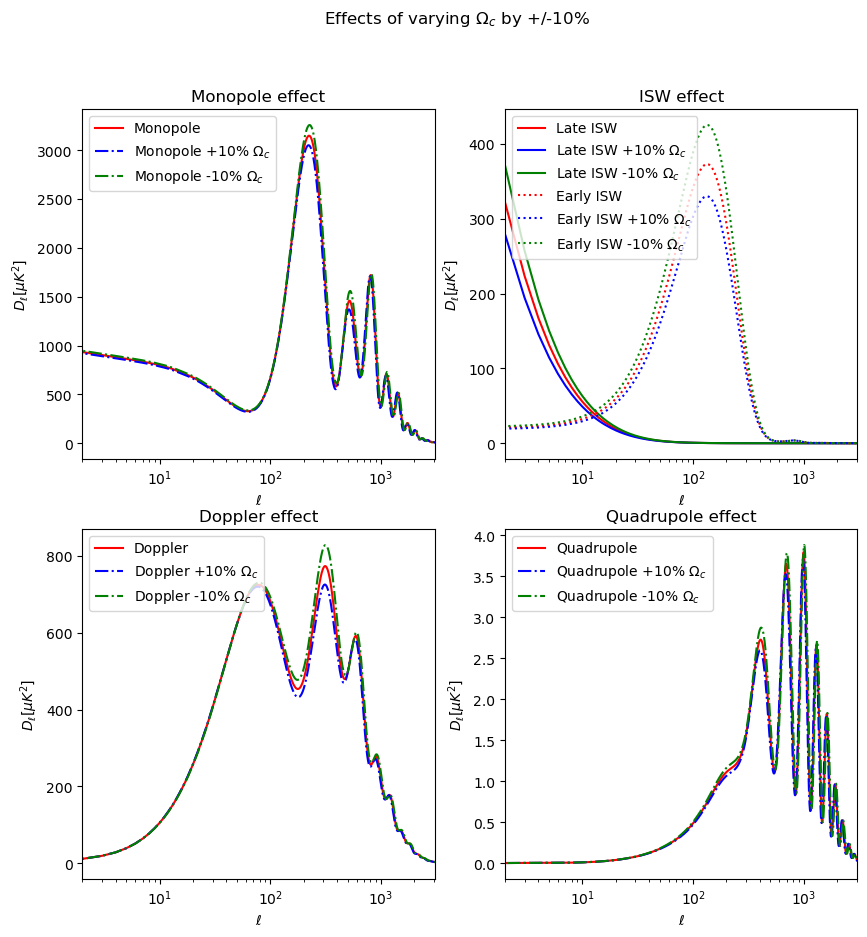

In [29]:
omega_c_pars_minus.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)
omega_c_pars_plus.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)

omega_c_data_plus = camb.get_results(omega_c_pars_plus)
omega_c_data_minus = camb.get_results(omega_c_pars_minus)

omega_c_dic_plus = omega_c_data_plus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')
omega_c_dic_minus = omega_c_data_minus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')

# Plot in a grid of plots, monopole, dipole, ISW and quadrupole

# Subplot for monopole
plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle('Effects of varying $\Omega_c$ by +/-10%')
plt.subplot(221)
plt.semilogx(ls_TT,dic['monxmon'], color='r')
plt.semilogx(ls_TT,omega_c_dic_plus['monxmon'], color='b',ls = '-.')
plt.semilogx(ls_TT,omega_c_dic_minus['monxmon'], color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Monopole','Monopole +10% $\Omega_c$','Monopole -10% $\Omega_c$'], loc = 'upper left')
plt.title('Monopole effect')

# Subplot for ISW effect
plt.subplot(222)
plt.semilogx(ls_TT,dic['LISWxLISW'], color='r', ls = '-')
plt.semilogx(ls_TT,omega_c_dic_plus['LISWxLISW'], color='b',ls = '-')
plt.semilogx(ls_TT,omega_c_dic_minus['LISWxLISW'], color='g',ls = '-')
plt.semilogx(ls_TT,dic['eISWxeISW'], ls=':', color='r')
plt.semilogx(ls_TT,omega_c_dic_plus['eISWxeISW'], ls=':', color='b')
plt.semilogx(ls_TT,omega_c_dic_minus['eISWxeISW'], ls=':', color='g')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Late ISW','Late ISW +10% $\Omega_c$','Late ISW -10% $\Omega_c$','Early ISW','Early ISW +10% $\Omega_c$','Early ISW -10% $\Omega_c$'], loc = 'upper left')
plt.title('ISW effect')

# Subplot for dipole effect
plt.subplot(223)
plt.semilogx(ls_TT,dic['dopxdop'],color='r')
plt.semilogx(ls_TT,omega_c_dic_plus['dopxdop'],color='b',ls = '-.')
plt.semilogx(ls_TT,omega_c_dic_minus['dopxdop'],color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Doppler','Doppler +10% $\Omega_c$','Doppler -10% $\Omega_c$'], loc = 'upper left')
plt.title('Doppler effect')

# Subplot for quadrupole effect
plt.subplot(224)
plt.semilogx(ls_TT,dic['QxQ'], color='r')
plt.semilogx(ls_TT,omega_c_dic_plus['QxQ'], color='b',ls = '-.')
plt.semilogx(ls_TT,omega_c_dic_minus['QxQ'], color='g',ls = '-.')
plt.xlabel('$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Quadrupole','Quadrupole +10% $\Omega_c$','Quadrupole -10% $\Omega_c$'], loc = 'upper left')
plt.title('Quadrupole effect')

$\Omega_c h^2$ (Physical Cold Dark Matter Density)

A $\pm 10\%$ variation in the physical cold dark matter density parameter, $\Omega_c h^2$, produces a noticeable effect, primarily on the first acoustic peaks of the TT power spectrum.Reducing $\Omega_c h^2$ leads to a slight amplification of the first peaks.Conversely, increasing $\Omega_c h^2$ results in these early peaks being slightly dampened.

At high multipoles (large $\ell$), the effect is very weak or essentially negligible.This behavior occurs because $\Omega_c h^2$ directly controls the epoch of matter-radiation equality. A lower amount of dark matter means the universe remains in a radiation-dominated phase for a longer period. This delay amplifies the Early Integrated Sachs-Wolfe (eISW) effect, thereby driving up the amplitude of the first acoustic peaks. Naturally, increasing $\Omega_c h^2$ produces the exact opposite effect.

When examining the individual physical contributions (Monopole, Doppler, ISW, etc.), this change is overwhelmingly driven by the eISW component. It dictates the trend described above and operates specifically at low to intermediate multipoles ($\ell$), while the high-$\ell$ regions of the spectrum remain largely unaffected.